In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def detect_lanes(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    edges = cv2.Canny(blurred, 50, 150)
    
    height, width = edges.shape
    mask = np.zeros_like(edges)
    
    polygon = np.array([[
        (0, height),
        (width // 2 - 50, height // 2 + 50),
        (width // 2 + 50, height // 2 + 50),
        (width, height)
    ]], np.int32)
    cv2.fillPoly(mask, polygon, 255)
    
    masked_edges = cv2.bitwise_and(edges, mask)
    
    lines = cv2.HoughLinesP(masked_edges, 1, np.pi/180, 100, minLineLength=50, maxLineGap=50)
    
    return lines

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [109..611].


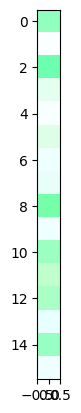

In [13]:
img = cv2.imread('images.jpg')

result = detect_lanes(img)

plt.imshow(result)